In [11]:
import sys
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from src.causal_tracing import CausalTracer, extract_subject_from_prompt
from src.data_utils import DatasetGenerator
from transformers import GPT2LMHeadModel, GPT2Tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [12]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [13]:
import json
with open("../data/processed/forget.json", 'r') as f:
    forget_data = json.load(f)

print(f"Loaded {len(forget_data)} forget prompts")

Loaded 59 forget prompts


In [14]:
tracer = CausalTracer(
    model=model,
    tokenizer=tokenizer,
    device=device,
    noise_std_multiplier=3.0
)

### Testing on a single prompt first

In [15]:
test_prompt = forget_data[0]
print(f"Testing on: '{test_prompt['text']}'")
print(f"Target: {test_prompt['target']}")

# Extract subject (the landmark name)
subject = extract_subject_from_prompt(test_prompt['text'], test_prompt['target'])
print(f"Subject: {subject}")

result = tracer.trace_single_prompt(
    prompt=test_prompt['text'],
    subject=subject,
    target=test_prompt['target']
)

print(f"\nClean probability: {result.clean_prob:.4f}")
print(f"Corrupted probability: {result.corrupted_prob:.4f}")
print(f"Recovery scores shape: {result.recovery_scores.shape}")

Testing on: 'The Eiffel Tower is a famous attraction in'
Target: Paris
Subject: Eiffel Tower

Clean probability: 0.0625
Corrupted probability: 0.0014
Recovery scores shape: (12, 4)


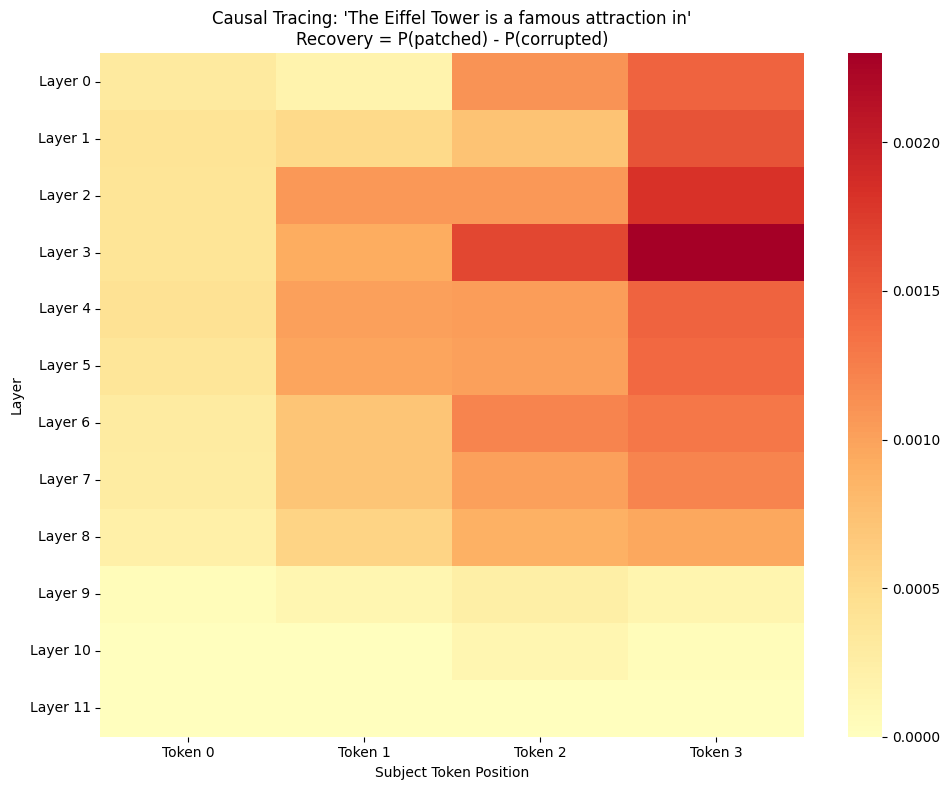

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
num_layers = model.config.n_layer
sns.heatmap(
    result.recovery_scores,
    ax=ax,
    cmap='RdYlBu_r',
    center=0,
    xticklabels=[f"Token {i}" for i in range(result.recovery_scores.shape[1])],
    yticklabels=[f"Layer {i}" for i in range(num_layers)]
)
ax.set_xlabel("Subject Token Position")
ax.set_ylabel("Layer")
ax.set_title(f"Causal Tracing: '{test_prompt['text']}'\nRecovery = P(patched) - P(corrupted)")
plt.tight_layout()
plt.savefig("../figures/causal_tracing_single.png", dpi=150)
plt.show()

In [17]:
tracing_prompts = []
for p in forget_data:  
    subject = extract_subject_from_prompt(p['text'], p['target'])
    tracing_prompts.append({
        'prompt': p['text'],
        'subject': subject,
        'target': p['target']
    })

print(f"Running causal tracing on {len(tracing_prompts)} prompts...")
results = tracer.trace_dataset(tracing_prompts, progress=True)

Running causal tracing on 59 prompts...


100%|██████████| 59/59 [00:43<00:00,  1.36it/s]


In [18]:
avg_recovery = tracer.aggregate_results(results)
print(f"Aggregated recovery scores shape: {avg_recovery.shape}")

layer_importance = avg_recovery.mean(axis=1)  # Average over subject positions
critical_layer = np.argmax(layer_importance)
print(f"\nCritical layer (highest average recovery): Layer {critical_layer}")

Aggregated recovery scores shape: (12, 6)

Critical layer (highest average recovery): Layer 3


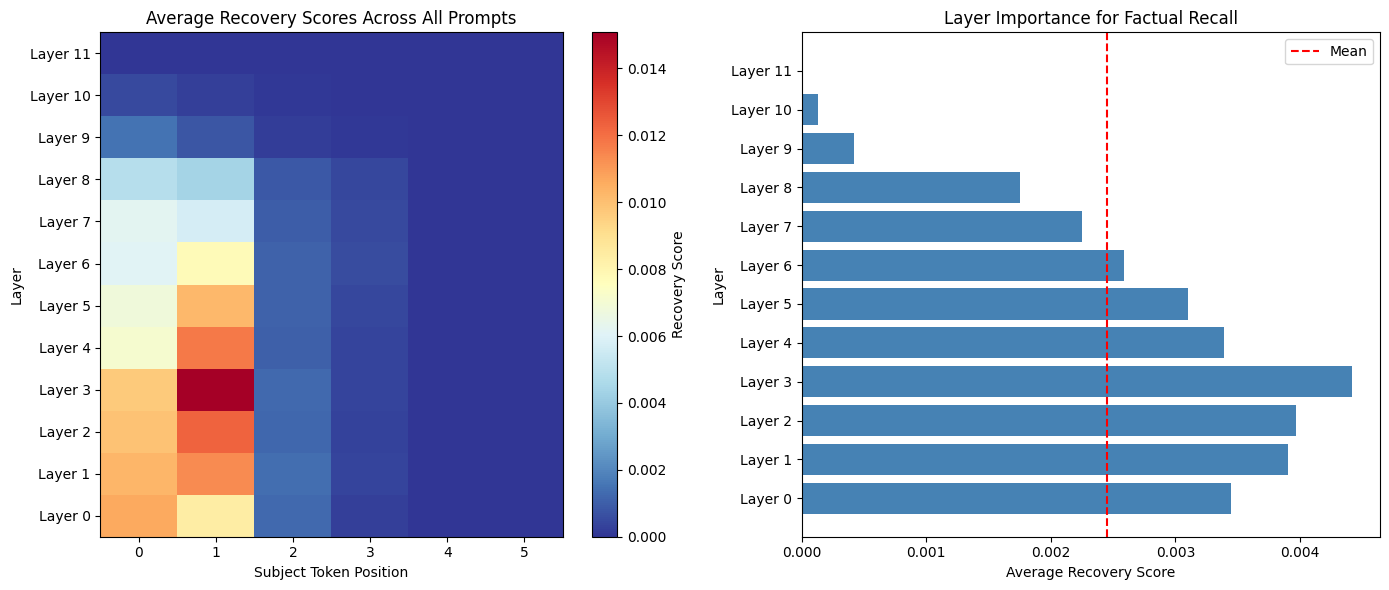

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
num_layers = model.config.n_layer

# Heatmap
ax1 = axes[0]
im = ax1.imshow(avg_recovery, aspect='auto', cmap='RdYlBu_r', origin='lower')
ax1.set_xlabel("Subject Token Position")
ax1.set_ylabel("Layer")
ax1.set_title("Average Recovery Scores Across All Prompts")
ax1.set_yticks(range(num_layers))
ax1.set_yticklabels([f"Layer {i}" for i in range(num_layers)])
plt.colorbar(im, ax=ax1, label="Recovery Score")

# Layer importance bar chart
ax2 = axes[1]
ax2.barh(range(num_layers), layer_importance, color='steelblue')
ax2.axvline(x=layer_importance.mean(), color='red', linestyle='--', label='Mean')
ax2.set_xlabel("Average Recovery Score")
ax2.set_ylabel("Layer")
ax2.set_title("Layer Importance for Factual Recall")
ax2.set_yticks(range(num_layers))
ax2.set_yticklabels([f"Layer {i}" for i in range(num_layers)])
ax2.legend()

plt.tight_layout()
plt.savefig("../figures/causal_tracing_heatmap.png", dpi=150)
plt.show()


In [20]:
from pathlib import Path

out_dir = Path("../results/causal_tracing")
out_dir.mkdir(parents=True, exist_ok=True)
np.save(out_dir / "recovery_scores.npy", avg_recovery)
np.save("../results/causal_tracing/recovery_scores.npy", avg_recovery)


summary = {
    'critical_layer': int(critical_layer),
    'layer_importance': layer_importance.tolist(),
    'num_prompts': len(results),
    'noise_std_multiplier': tracer.noise_std_multiplier
}

import json
with open("../results/causal_tracing/summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nResults saved!")
print(f"Critical layer identified: Layer {critical_layer}")


Results saved!
Critical layer identified: Layer 3
